In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [2]:
X= 6 * np.random.rand(200,1) -3
y= 0.8* X**2+0.9*X+2+np.random.randn(200,1)

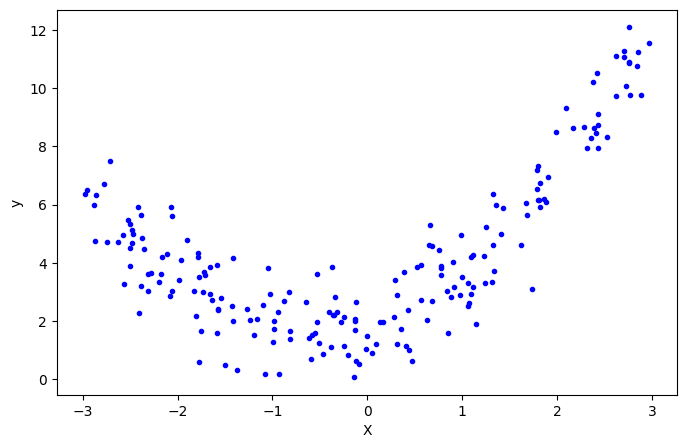

In [3]:
plt.figure(figsize=(8,5))
plt.plot(X,y,"b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [5]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
y_pred=lr.predict(X_test)
r2_score(y_test,y_pred)

0.3340660787898605

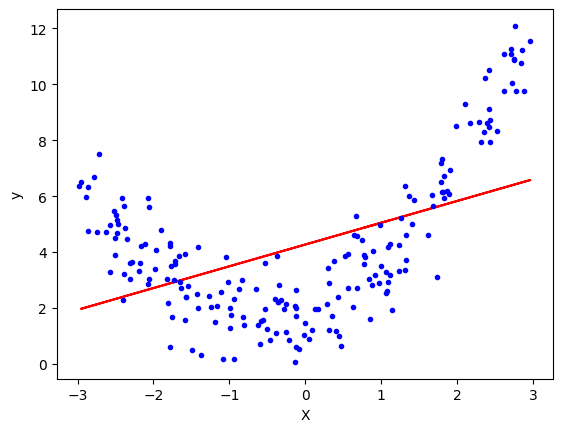

In [7]:
plt.plot(X_train,lr.predict(X_train),color="r")
plt.plot(X,y,"b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [8]:
poly= PolynomialFeatures(degree=2,include_bias=True)

In [9]:
X_train_trans=poly.fit_transform(X_train)
X_test_trans=poly.fit_transform(X_test)

In [10]:
print(X_train[0])
print(X_train_trans[0])

[1.09286537]
[1.         1.09286537 1.19435471]


In [11]:
lr=LinearRegression()
lr.fit(X_train_trans,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred=lr.predict(X_test_trans)
r2_score(y_test,y_pred)

0.8713759782837784

In [13]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.91936448 0.84480434]]
[1.89843132]


In [14]:
X_new= np.linspace(-3,3,200).reshape(200,1)
X_new_trans=poly.transform(X_new)
y_new=lr.predict(X_new_trans)

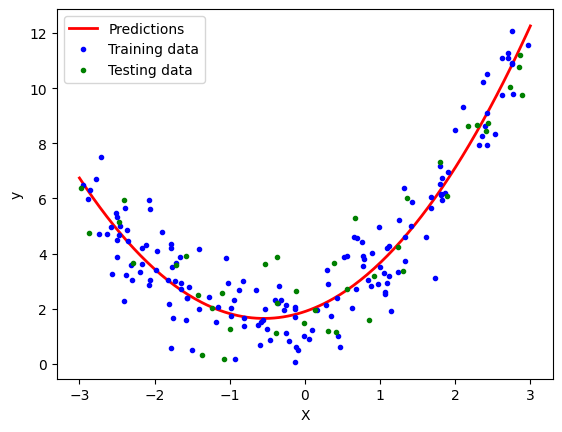

In [15]:
plt.plot(X_new,y_new,"r-",label="Predictions",linewidth=2)
plt.plot(X_train,y_train,"b.",label="Training data")
plt.plot(X_test,y_test,"g.",label="Testing data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [16]:
# APPLYING POLYNOMIAL REGRESSION USING PIPELINE
def polynomail_regression(degree):
    X_new=np.linspace(-3,3,200).reshape(200,1)
    X_new_poly=poly.transform(X_new)
    
    poly_bigfeatures=PolynomialFeatures(degree=degree,include_bias=False)
    std_sclaer=StandardScaler()
    lin_reg=LinearRegression()
    ploynomail_regression=Pipeline([
        ("poly_features",poly_bigfeatures),
        ("std_scaler",std_sclaer),
        ("lin_reg",lin_reg)
    ])
    ploynomail_regression.fit(X_train,y_train)
    y_newbig=ploynomail_regression.predict(X_new)
    plt.plot(X_new,y_newbig,"r-",label="Predictions",linewidth=2)
    
    plt.plot(X_train,y_train,"b.",label="Training data")
    plt.plot(X_test,y_test,"g.",label="Testing data")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3,3,0,10])
    plt.legend()
    plt.show()


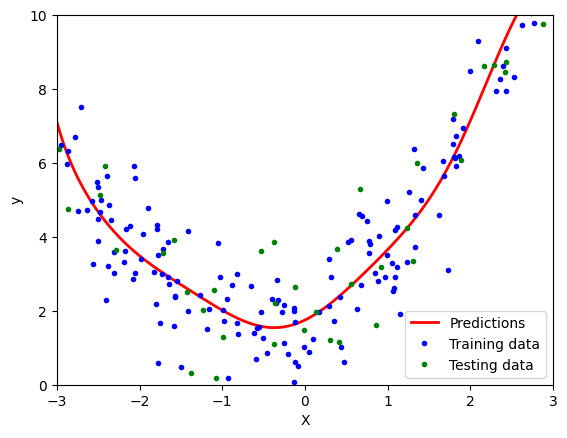

In [17]:
polynomail_regression(10)

In [18]:
# APPLYING GRADIENT DESCENT 


In [19]:
x= 7*np.random.rand(100,1)-2.8
y= 7*np.random.rand(100,1)-2.8   

z=x**2+y**2+0.2*x+0.2*y+0.1*x*y+2+np.random.randn(100,1)

In [20]:
import plotly.express as px
df=px.data.iris()
fig=px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [21]:
lr=LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input=np.linspace(x.min(),x.max(),10)
y_input=np.linspace(y.min(),y.max(),10)
xGrid, yGrid=np.meshgrid(x_input,y_input)

final=np.vstack((xGrid.ravel().reshape(100,),yGrid.ravel().reshape(100,))).T
z_final=lr.predict(final).reshape(10,10)

In [22]:
import plotly.graph_objects as go
fig=px.scatter_3d(x=x.ravel(),y=y.ravel(),z=z.ravel()) 
fig.add_surface(x=x_input, y=y_input, z=z_final)
fig.show()

In [23]:
x_multi=np.array([x,y]).reshape(100,2)
x_multi.shape

(100, 2)

In [24]:
poly=PolynomialFeatures(degree=6)
x_multi_trans=poly.fit_transform(x_multi)

In [25]:
print('Input',poly.n_features_in_)
print('Output',poly.n_output_features_)
print('Powers\n',poly.powers_)

Input 2
Output 28
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]
 [4 0]
 [3 1]
 [2 2]
 [1 3]
 [0 4]
 [5 0]
 [4 1]
 [3 2]
 [2 3]
 [1 4]
 [0 5]
 [6 0]
 [5 1]
 [4 2]
 [3 3]
 [2 4]
 [1 5]
 [0 6]]


In [26]:
x_multi_trans.shape

(100, 28)

In [27]:
lr=LinearRegression()
lr.fit(x_multi_trans,z)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
x_test_multi=poly.transform(final)

In [29]:
z_final=lr.predict(x_test_multi).reshape(10,10)

In [30]:
fig=px.scatter_3d(x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))
fig.update_layout(scene=dict(zaxis=dict(range=[0,35])))
fig.show()